In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('data//1_preprocessed//preprocessed_dataset.csv')

y = data.track_genre
X = data[['duration_ms','explicit','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']]

# Stratified split to maintain class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Build a per-genre mean feature profile
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

genre_profiles = X_all.groupby(y_all).mean()  # shape: (114, 14)
print(genre_profiles.shape)  # (114, 14)

# Scale — important for clustering
scaler = StandardScaler()
genre_profiles_scaled = scaler.fit_transform(genre_profiles)

(114, 14)


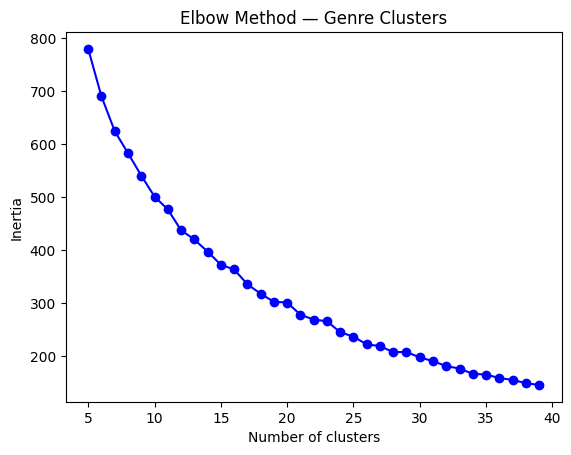

In [3]:
# Elbow method
inertias = []
K = range(5, 40)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(genre_profiles_scaled)
    inertias.append(km.inertia_)

plt.plot(K, inertias, "bo-")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method — Genre Clusters")
plt.show()

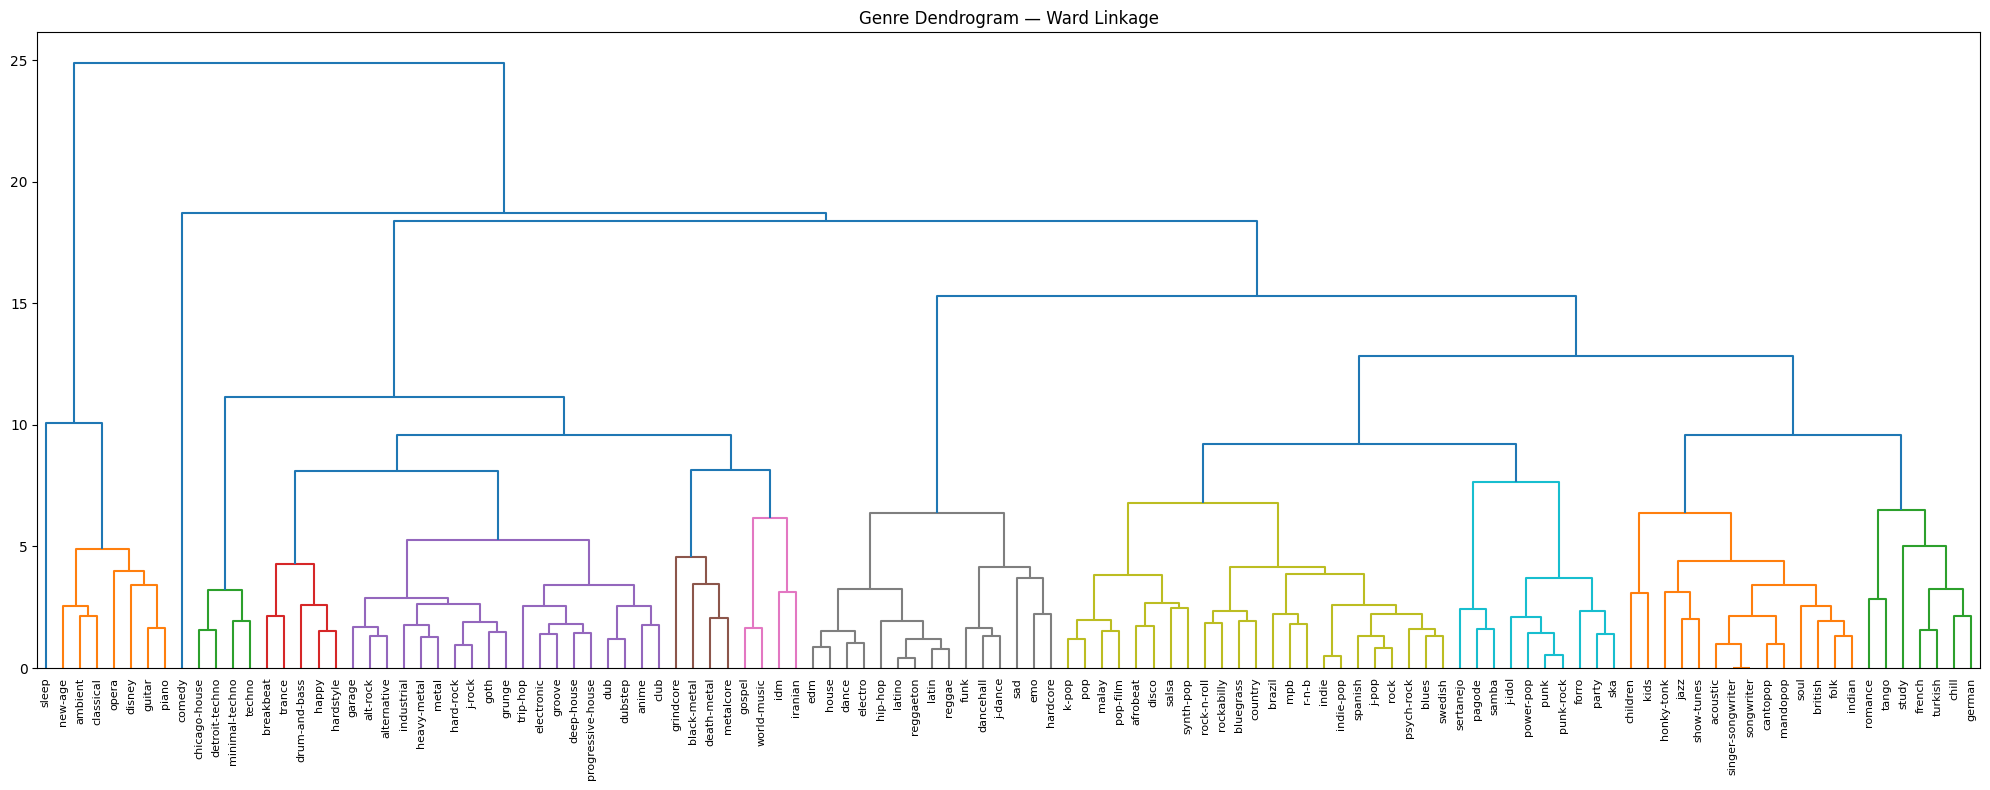

In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from matplotlib import pyplot as plt

# Compute linkage
linked = linkage(genre_profiles_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(20, 8))
dendrogram(
    linked,
    labels=genre_profiles.index.tolist(),
    orientation="top",
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=8
)
plt.title("Genre Dendrogram — Ward Linkage")
plt.tight_layout()
plt.show()

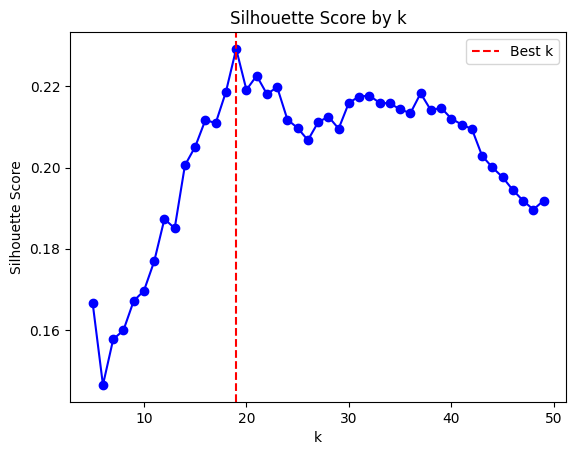

Best k: 19, Score: 0.2292


In [5]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

silhouette_scores = {}

for k in range(5, 50):
    labels = fcluster(linked, k, criterion="maxclust")
    score = silhouette_score(genre_profiles_scaled, labels)
    silhouette_scores[k] = score

# Plot
plt.plot(list(silhouette_scores.keys()), 
         list(silhouette_scores.values()), "bo-")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.axvline(max(silhouette_scores, key=silhouette_scores.get), 
            color="red", linestyle="--", label="Best k")
plt.legend()
plt.show()

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Best k: {best_k}, Score: {silhouette_scores[best_k]:.4f}")

In [8]:
k = 30
cluster_labels = fcluster(linked, k, criterion="maxclust")

# Create genre → cluster mapping
genre_to_cluster = dict(zip(genre_profiles.index, cluster_labels))
print(pd.Series(genre_to_cluster).sort_values())

# See what's in each cluster
cluster_df = pd.DataFrame({
    "genre": genre_profiles.index,
    "cluster": cluster_labels
}).sort_values("cluster")

for c, grp in cluster_df.groupby("cluster"):
    print(f"\nCluster {c}: {grp['genre'].tolist()}")

# Map your target variable
y_train_merged = y_train.map(genre_to_cluster)
y_test_merged  = y_test.map(genre_to_cluster)

ambient       1
classical     1
new-age       1
disney        2
piano         2
             ..
german       28
chill        28
french       28
study        29
comedy       30
Length: 114, dtype: int32

Cluster 1: ['ambient', 'classical', 'new-age']

Cluster 2: ['disney', 'piano', 'guitar']

Cluster 3: ['opera']

Cluster 4: ['sleep']

Cluster 5: ['detroit-techno', 'chicago-house', 'minimal-techno', 'techno']

Cluster 6: ['breakbeat', 'trance']

Cluster 7: ['happy', 'drum-and-bass', 'hardstyle']

Cluster 8: ['goth', 'j-rock', 'grunge', 'garage', 'heavy-metal', 'hard-rock', 'alternative', 'metal', 'industrial', 'alt-rock']

Cluster 9: ['deep-house', 'electronic', 'groove', 'club', 'dub', 'dubstep', 'anime', 'progressive-house', 'trip-hop']

Cluster 10: ['black-metal', 'metalcore', 'death-metal']

Cluster 11: ['grindcore']

Cluster 12: ['world-music', 'gospel']

Cluster 13: ['idm', 'iranian']

Cluster 14: ['house', 'hip-hop', 'edm', 'electro', 'latino', 'latin', 'reggaeton', 'reggae', 'da

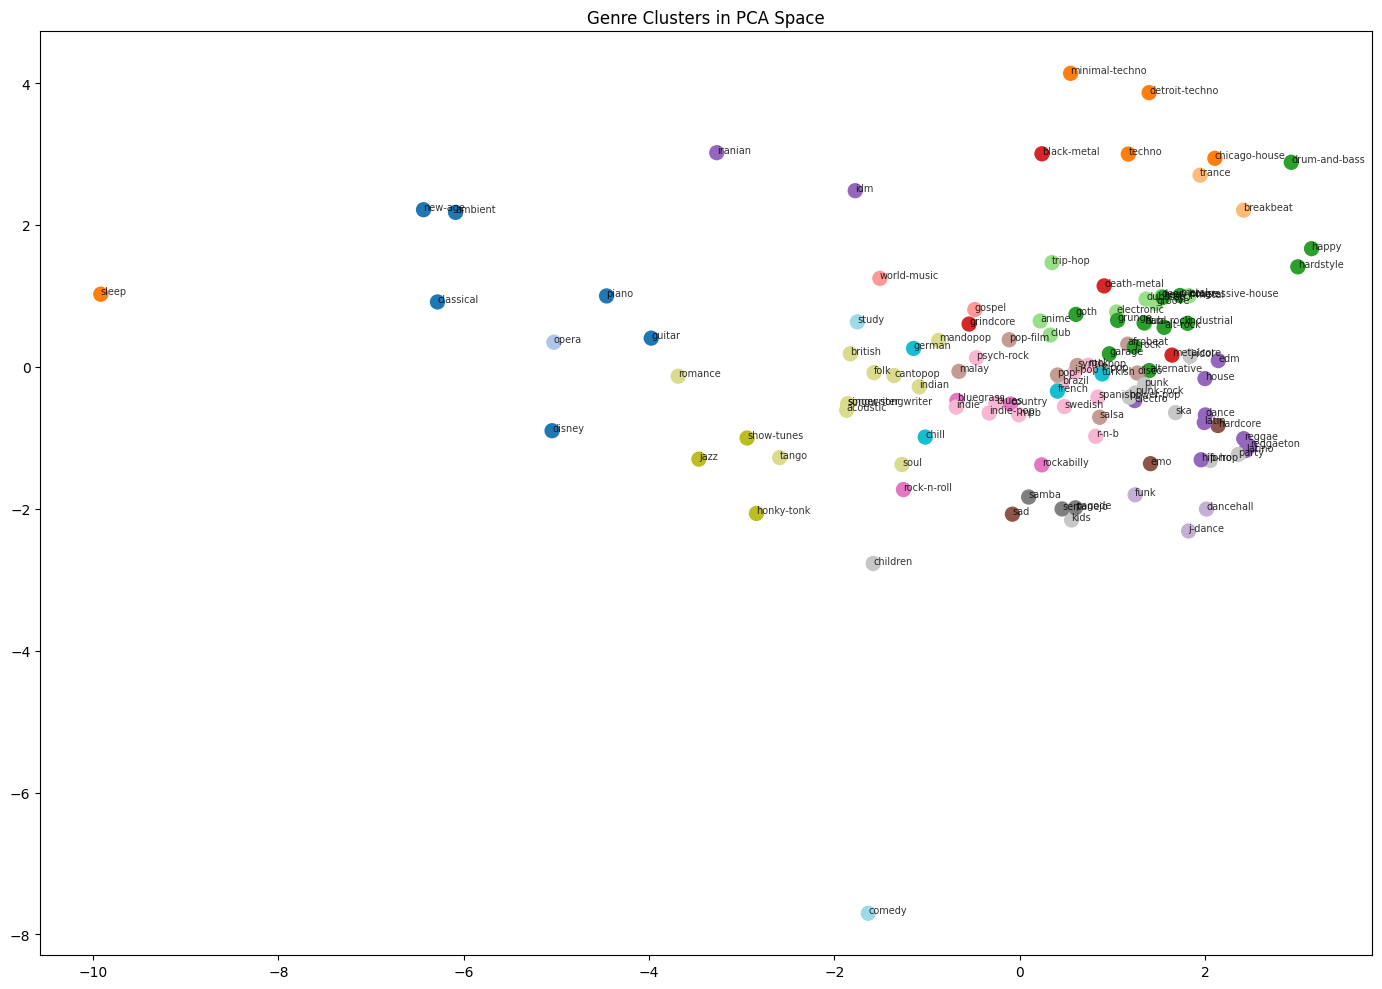

In [9]:
pca = PCA(n_components=2)
coords = pca.fit_transform(genre_profiles_scaled)

plt.figure(figsize=(14, 10))
scatter = plt.scatter(coords[:, 0], coords[:, 1], 
                      c=cluster_labels, cmap="tab20", s=100)

for i, genre in enumerate(genre_profiles.index):
    plt.annotate(genre, (coords[i, 0], coords[i, 1]), 
                 fontsize=7, alpha=0.8)

plt.title("Genre Clusters in PCA Space")
plt.tight_layout()
plt.show()

In [11]:
# Add cluster labels to data
data["genre_cluster"] = data.track_genre.map(genre_to_cluster)
data.to_csv('data//1_preprocessed//preprocessed_dataset_with_clusters.csv', index=False)
# Save the mapping for later use
pd.Series(genre_to_cluster).to_csv('data//1_preprocessed//genre_to_cluster_mapping.csv')